# **1. Load and process data**

### 1.1. Parameters, packages and paths

In [153]:
# Core constants
CRUDE_BARREL_TO_TONS = 7.33  # barrel of crude per ton
BUFFER_KM = 10  # km radius for spatial buffer queries

discount_rate = 0.03 #OnStove uses 0.03 for social perspective, 0.15 for private perspective

# Default LPG price (FOB) 
default_LPG_price = 0.6  # USD/kg, used when user input is missing

# Ports parameters
STS_cost = 0.1  # US$/kg
pre_bottling_cost = 0.2  # 20% TO BE MODIFIED

# Border points parameters
border_point_time_hours = 39
ferry_cost_per_km = 0.78  # US$/ton/straight line km
ferry_time_per_km = 0.071  # hours/straight line km

# Driver parameters
driver_annual_salary_usd = 2604
salary_multiplier = 1.18
hours_per_day = 8 # working hours per day
days_per_year = 330 # working days per year

# Tankers parameters
tanker_capacity_kg = 24000
utilization_factor = 0.85
variable_cost_per_km = 0.635
tanker_overnight_cost_usd = 197673 
tanker_life_years = 35
license_cost_usd = 418
licence_life_years = 5
fixed_loading_unloading_hours = 1.0
tanker_annual_km = 42000 

# Stove parameters (OnStove defaults) (used for storage cost calculation and capacity estimation)
meals_per_day = 1.0
energy_per_meal_mj = 3.64
efficiency = 0.5
energy_content_mj_per_kg = 45.5
density_kg_per_l = 0.5
kg_per_m3 = 1000.0 * density_kg_per_l

# primary storage cost calculation options
USE_DEFAULT_RESIDENCE_TIME = True # Set to True for a fixed 15-day residence time
USE_DIFFERENTIATED_cost_storageS = False # Set to True for V1 (differentiated), False for V2 (average)

# Storage parameters
storage_overnight_cost_usd_kg = 12.5
storage_installation_fee = 760.0
storage_license_cost_usd = 3952.0
storage_life_years = 50
storage_license_life_years = 3
discount_rate_storage = float(globals().get("discount_rate", 0.03))
storage_cap = 0.25 #US$/kg, maximum price for storage cost, used to cap outliers in the data when USED_DIFFERENTIATED_cost_storageS is True

# Core dependencies for tabular, spatial, and raster work
import pandas as pd
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt 
import numpy as np
import rasterio
from rasterio.mask import mask as raster_mask
from rasterio.features import shapes
import shapely
from shapely.geometry import Point, box, shape, LineString
from skimage.graph import MCP_Geometric
from pyproj import Geod, CRS
from onstove.layer import VectorLayer, RasterLayer
from shapely.ops import nearest_points
from scipy.optimize import linprog
from openpyxl import Workbook
import warnings

# Default gpkg and layer names used when user files are missing
DEFAULT_GPKG = data_dir / "default.gpkg"
DEFAULT_LAYERS = {
    'refineries': 'refineries',
    'ports': 'ports',
    'gas_plants': 'gas_plants',
    'primary_storage': 'primary_storage',
    'border_points': 'border_points',
}

### [FUNCTIONS DEFINITION] data loading and fill missing values

In [154]:
def _as_vector_layer(gdf, name="mask"):
    """
    Wrap a GeoDataFrame in a VectorLayer for in-memory masking.
    Avoids writing temporary files and keeps attributes intact.
    Returns a VectorLayer ready for VectorLayer.mask.
    """
    vect = VectorLayer(name=name)
    vect.data = gdf.copy()
    return vect


def load_raster_means(raster_path, band_names, mask_gdf):
    """
    Clip each band by mask and compute mean values.
    Returns a single-column DataFrame indexed by band names.
    Raises if any band has no valid pixels inside the mask.
    """
    if not raster_path.exists():
        raise FileNotFoundError(f"Missing raster file: {raster_path}")

    if mask_gdf.crs is None:
        raise ValueError("mask_layer has no CRS")

    mask_vect = _as_vector_layer(mask_gdf, name="mask_layer")
    values = {}

    for band_idx, band_name in enumerate(band_names, start=1):
        raster = RasterLayer(name=f"{raster_path.stem}_{band_name}", path=str(raster_path), band=band_idx)
        raster.mask(mask_vect, crop=True, all_touched=False)

        arr = raster.data.astype(np.float64)
        nodata = raster.meta.get('nodata')
        if nodata is not None:
            if pd.notna(nodata):
                arr[arr == nodata] = np.nan

        mean_val = np.nanmean(arr)
        if np.isnan(mean_val):
            raise ValueError(
                f"Band '{band_name}' in {raster_path.name} has no valid data inside mask_layer"
            )
        values[band_name] = float(mean_val)

    result = pd.DataFrame.from_dict(values, orient='index')
    result.columns = [1]
    return result


def load_or_use_default(gpkg_name, default_gpkg_path, default_layer_name, mask_gdf, data_dir=data_dir):
    """
    Load a layer from user data or defaults, then clip it to mask_gdf.
    Returns a GeoDataFrame with a stable id_supply column.
    No files are written during the fallback path.
    """
    gpkg_path = data_dir / f"{gpkg_name}.gpkg"
    mask_vect = _as_vector_layer(mask_gdf, name="mask_layer")

    if gpkg_path.exists():
        # Phase 1: User data found
        layer = VectorLayer(name=gpkg_name, path=str(gpkg_path))
        layer.mask(mask_vect, keep_geom_type=False)
        gdf = layer.data
        gdf = gdf.reset_index(drop=True)
        gdf['id_supply'] = [f"{gpkg_name}_{i}" for i in range(len(gdf))]
        print(f"{gpkg_name}: loaded and clipped in memory ({len(gdf)} records)")
        return gdf

    # Phase 2: Use default.gpkg layer and clip with mask_layer (no file creation)
    if not default_gpkg_path.exists():
        raise FileNotFoundError(f"Missing default gpkg: {default_gpkg_path}")

    default_gdf = gpd.read_file(default_gpkg_path, layer=default_layer_name)
    default_layer = _as_vector_layer(default_gdf, name=gpkg_name)
    default_layer.mask(mask_vect, keep_geom_type=False)

    gdf = default_layer.data
    gdf = gdf.reset_index(drop=True)
    gdf['id_supply'] = [f"{gpkg_name}_{i}" for i in range(len(gdf))]
    print(f"{gpkg_name}: clipped from default.gpkg/{default_layer_name} in memory ({len(gdf)} records)")
    return gdf


def load_border_points_or_default(mask_gdf, data_dir=data_dir, near_km=5):
    """
    Load border points, then keep, snap, or drop by distance to mask_gdf.
    Points within near_km get snapped to the mask boundary.
    Returns a GeoDataFrame with id_supply and original attributes.
    """
    user_path = data_dir / "border_points.gpkg"

    if user_path.exists():
        try:
            points = gpd.read_file(user_path, layer="border_points")
        except Exception:
            points = gpd.read_file(user_path)
        source_name = f"{user_path.name}"
    else:
        if not DEFAULT_GPKG.exists():
            raise FileNotFoundError(f"Missing default gpkg: {DEFAULT_GPKG}")
        points = gpd.read_file(DEFAULT_GPKG, layer=DEFAULT_LAYERS['border_points'])
        source_name = f"default.gpkg/{DEFAULT_LAYERS['border_points']}"

    if points.empty:
        print(f"border_points: loaded 0 records from {source_name}")
        points = points.reset_index(drop=True)
        points['id_supply'] = [f"border_points_{i}" for i in range(len(points))]
        return points

    if mask_gdf.crs is None:
        raise ValueError("mask_layer has no CRS")
    if points.crs is None:
        raise ValueError("border_points has no CRS")

    pts = points.to_crs(mask_gdf.crs).copy()

    pts_m = pts.to_crs("EPSG:3857").copy()
    mask_m = mask_gdf.to_crs("EPSG:3857")
    mask_union_m = mask_m.geometry.union_all()

    inside_count = 0
    moved_count = 0
    dropped_count = 0

    keep_rows = []
    new_geom_m = []

    for idx, geom_m in zip(pts_m.index, pts_m.geometry):
        if geom_m is None or geom_m.is_empty:
            dropped_count += 1
            continue

        if mask_union_m.covers(geom_m):
            inside_count += 1
            keep_rows.append(idx)
            new_geom_m.append(geom_m)
            continue

        dist_m = float(geom_m.distance(mask_union_m))
        if dist_m <= near_km * 1000:
            snapped = nearest_points(geom_m, mask_union_m)[1]
            moved_count += 1
            keep_rows.append(idx)
            new_geom_m.append(snapped)
        else:
            dropped_count += 1

    if len(keep_rows) == 0:
        out = pts.iloc[0:0].copy()
    else:
        out_m = pts_m.loc[keep_rows].copy()
        out_m.geometry = new_geom_m
        out = out_m.to_crs(mask_gdf.crs)

    out = out.reset_index(drop=True)
    out['id_supply'] = [f"border_points_{i}" for i in range(len(out))]
    print(
        f"border_points: loaded from {source_name} | inside={inside_count}, moved_to_mask={moved_count}, dropped_far={dropped_count}"
    )
    return out


def _metric_crs_for_gdf(gdf):
    """
    Return a metric CRS for distance operations.
    If input is projected, return its CRS.
    If geographic, derive a local azimuthal projection from the centroid.
    Raises if CRS is missing or geometry is empty.
    """
    if gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")
    if not gdf.crs.is_geographic:
        return gdf.crs
    centroid = gdf.geometry.union_all().centroid
    if centroid.is_empty:
        raise ValueError("Cannot derive metric CRS from empty geometry")
    return CRS.from_proj4(
        f"+proj=aeqd +lat_0={centroid.y} +lon_0={centroid.x} +datum=WGS84 +units=m +no_defs"
    )


def _metric_views_for_buffer(gdf, other_gdf):
    """
    Return both layers in a metric CRS for buffering.
    If input is geographic, reproject both to a local metric CRS.
    Otherwise return the inputs unchanged.
    """
    metric_crs = _metric_crs_for_gdf(gdf)
    if gdf.crs.is_geographic:
        return gdf.to_crs(metric_crs), other_gdf.to_crs(metric_crs)
    return gdf, other_gdf


def fill_from_buffer(gdf, default_gdf, cols, buffer_km=BUFFER_KM):
    """
    Fill missing values by searching nearby features within a buffer radius.
    Uses a metric CRS to compute distances safely.
    Keeps original geometry and CRS on output.
    """
    gdf, default_gdf = gdf.copy(), default_gdf.to_crs(gdf.crs)
    if gdf.crs is None or default_gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")
    gdf_metric, default_metric = _metric_views_for_buffer(gdf, default_gdf)
    buffer_dist = buffer_km * 1000.0

    for col in cols:
        if col not in gdf.columns:
            continue
        missing_idx = gdf[gdf[col].isna() | (gdf[col] == '')].index
        if len(missing_idx) == 0:
            continue

        for idx in missing_idx:
            geom = gdf_metric.loc[idx, 'geometry']
            if geom is None or geom.is_empty:
                continue
            port_buffer = geom.buffer(buffer_dist)
            nearby = default_metric[default_metric.geometry.intersects(port_buffer)]

            if len(nearby) > 0 and col in nearby.columns:
                val = nearby[col].dropna()
                if len(val) > 0:
                    gdf.at[idx, col] = val.iloc[0]
    return gdf


def fill_lpg_price_from_raster(gdf, raster_path, band_index=1, overwrite=False):
    """
    Sample a raster at facility locations and fill LPG_price.
    Handles non-point geometries via centroids.
    Only fills missing values unless overwrite=True.
    """
    out = gdf.copy()

    if out.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")

    if 'LPG_price' not in out.columns:
        out['LPG_price'] = np.nan

    raster_file = Path(raster_path)
    if not raster_file.exists():
        raise FileNotFoundError(f"Missing LPG price raster: {raster_file}")

    with rasterio.open(raster_file) as src:
        if src.crs is None:
            raise ValueError("LPG price raster has no CRS")
        if band_index < 1 or band_index > src.count:
            raise ValueError(
                f"Requested band {band_index} for {raster_file.name}, but raster has {src.count} band(s)"
            )

        work = out.to_crs(src.crs).copy()
        geom_series = work.geometry
        if not work.geom_type.eq('Point').all():
            geom_series = work.geometry.centroid

        sampled_values = np.full(len(work), np.nan, dtype=np.float64)
        valid_positions = []
        valid_coords = []

        for pos, geom in enumerate(geom_series):
            if geom is None or geom.is_empty:
                continue
            valid_positions.append(pos)
            valid_coords.append((geom.x, geom.y))

        if len(valid_coords) > 0:
            for pos, sample in zip(valid_positions, src.sample(valid_coords, indexes=band_index)):
                sampled_values[pos] = float(sample[0])

        nodata = src.nodata
        if nodata is not None:
            sampled_values[sampled_values == nodata] = np.nan

    sampled_series = pd.Series(sampled_values, index=out.index)
    if overwrite:
        mask = sampled_series.notna()
    else:
        mask = out['LPG_price'].isna() & sampled_series.notna()

    out.loc[mask, 'LPG_price'] = sampled_series.loc[mask]
    return out


def _as_bool_series(series):
    """
    Normalize mixed-type flag values to booleans.
    Accepts common truthy strings and numeric flags.
    Missing values are treated as False.
    """
    def _to_bool(v):
        if isinstance(v, bool):
            return v
        if pd.isna(v):
            return False
        s = str(v).strip().lower()
        return s in {'true', '1', 'yes', 'y', 't'}

    return series.apply(_to_bool)


def redistribute_small_national_shares(nat_shares_df, min_share_pct=1.0):
    """
    Remove shares below a threshold and re-normalize to 100%.
    Preserves the original index and emits a sanity warning if needed.
    """
    if nat_shares_df.shape[1] == 0:
        raise ValueError("nat_shares_df has no numeric column")

    out = nat_shares_df.copy()
    share_col = out.columns[0]

    # Convert to numeric, handle missing values
    shares = pd.to_numeric(out[share_col], errors='coerce').fillna(0.0)
    
    # Sanity check: verify the initial data makes sense
    original_sum = float(shares.sum())
    if not (99.0 <= original_sum <= 101.0):
        print(f"WARNING: Original shares sum to {original_sum:.2f}%, not 100%. Check input data.")

    # Identify which shares to keep
    keep = shares >= float(min_share_pct)

    if keep.sum() == 0:
        raise ValueError(
            f"All supply modes are below the threshold ({min_share_pct}%). Cannot redistribute."
        )

    # Set dropped shares to 0
    redistributed = shares.where(keep, 0.0)
    total_keep = float(redistributed.sum())

    # Redistribute proportionally to reach 100%
    redistributed = redistributed * (100.0 / total_keep)
    out[share_col] = redistributed
    
    return out

### [FUNCTIONS DEFINITION] Facility processing

In [155]:
def process_refineries(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Fill missing values and add LPG price from raster sampling.
    Ensures crude capacity is numeric and non-null.
    Applies buffer-based defaults before raster sampling.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer
    fill_cols = ['crude_capacity', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure production and fill LPG_price from raster
    if 'crude_capacity' not in gdf.columns:
        gdf['crude_capacity'] = 0.0
    else:
        gdf['crude_capacity'] = pd.to_numeric(gdf['crude_capacity'], errors='coerce').fillna(0.0)

    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} refinery rows still have missing LPG_price after raster sampling")

    return gdf


def process_gas_plants(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Fill missing values and add LPG price from raster sampling.
    Normalizes LPG production to numeric values.
    Applies buffer-based defaults before raster sampling.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer
    fill_cols = ['LPG_prod', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure production and fill LPG_price from raster
    if 'LPG_prod' not in gdf.columns:
        gdf['LPG_prod'] = 0.0
    else:
        gdf['LPG_prod'] = pd.to_numeric(gdf['LPG_prod'], errors='coerce').fillna(0.0)

    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} gas plant rows still have missing LPG_price after raster sampling")

    return gdf


def process_ports(gdf, default_gdf, storage_gdf, lpg_price_raster_path, price_band=1):
    """
    Handles data cleaning, spatial linking with storage facilities, 
    and sampling the base LPG price from the raster.
    """
    gdf = gdf.copy()

    # Phase 1: Fill missing values from buffer
    fill_cols = ['VLGC_compliance', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure LPG_price exists and sample from raster
    if 'LPG_price' not in gdf.columns:
        gdf['LPG_price'] = np.nan
    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    # Phase 3: Initialize spatial and technical fields
    gdf['LPG_capacity'] = 0.0
    gdf['tanks_nearby'] = 0.0
    gdf['LPG_compliance'] = False

    # Ensure VLGC_compliance exists and handle NaNs
    if 'VLGC_compliance' not in gdf.columns:
        gdf['VLGC_compliance'] = False
    else:
        gdf['VLGC_compliance'] = gdf['VLGC_compliance'].fillna(False)

    # Phase 4: Spatial join with storage facilities
    if storage_gdf is not None:
        gdf = gdf.to_crs(storage_gdf.crs)
        gdf_metric, storage_metric = _metric_views_for_buffer(gdf, storage_gdf)
        buffer_dist = BUFFER_KM * 1000.0

        # Precompute buffers for all ports
        port_buffers = {idx: geom.buffer(buffer_dist) for idx, geom in gdf_metric.geometry.items()}

        # Count connections per storage to allow capacity de-duplication
        storage_connection_counts = {}
        for s_idx, s_row in storage_metric.iterrows():
            s_geom = s_row.geometry
            n_connected_ports = sum(1 for p_buf in port_buffers.values() if p_buf.intersects(s_geom))
            storage_connection_counts[s_idx] = n_connected_ports

        # Allocate capacity to ports based on nearby storage
        for idx, port_buffer in port_buffers.items():
            nearby = storage_metric[storage_metric.geometry.intersects(port_buffer)]
            if len(nearby) > 0:
                allocated_caps = []
                for s_idx, s_row in nearby.iterrows():
                    raw_cap = float(s_row['LPG_capacity']) if ('LPG_capacity' in nearby.columns and pd.notna(s_row.get('LPG_capacity'))) else 0.0
                    n_conn = storage_connection_counts.get(s_idx, 0)
                    if n_conn > 0:
                        allocated_caps.append(raw_cap / n_conn)

                gdf.at[idx, 'LPG_capacity'] = float(sum(allocated_caps))
                gdf.at[idx, 'tanks_nearby'] = len(nearby)
                gdf.at[idx, 'LPG_compliance'] = True
            else:
                gdf.at[idx, 'LPG_compliance'] = False

    return gdf


def process_primary_storage(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Ensure storage capacity fields exist and are numeric.
    Fills LPG_capacity from nearby defaults when missing.
    Initializes LPG_price as NaN for later steps.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer for LPG_capacity 
    fill_cols = ['LPG_capacity']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure storage capacity
    if 'LPG_capacity' not in gdf.columns:
        gdf['LPG_capacity'] = 0.0
    else:
        gdf['LPG_capacity'] = gdf['LPG_capacity'].fillna(0.0)

    gdf['LPG_price'] = np.nan

    return gdf


def process_border_points(gdf, default_gdf, nat_shares_df, lpg_price_raster_path, price_band=1):
    """
    Handles data initialization, spatial filling, raster sampling, 
    and supply share allocation for border points.
    """
    bp = gdf.copy()

    if bp.empty:
        for col in ['LPG_price', 'osbp', 'percentage', 'category']:
            bp[col] = pd.Series(dtype='float64' if col not in ['osbp', 'category'] else 'object')
        return bp

    # Phase 1: Initialize columns and handle missing data
    if 'LPG_price' not in bp.columns: bp['LPG_price'] = np.nan
    if 'osbp' not in bp.columns: 
        bp['osbp'] = np.nan
    else: 
        bp['osbp'] = bp['osbp'].replace('', np.nan)

    # Phase 2: Fill from buffer and raster
    bp = fill_from_buffer(bp, default_gdf, ['LPG_price', 'osbp'])
    bp = fill_lpg_price_from_raster(bp, lpg_price_raster_path, band_index=price_band, overwrite=False)
    
    bp['osbp'] = bp['osbp'].replace('', np.nan).fillna('no')

    # Phase 3: Share (percentage) logic
    border_share = float(nat_shares_df.loc['border_points'].iloc[0]) / 100.0

    if 'percentage' in bp.columns and bp['percentage'].notna().any():
        bp['percentage'] = bp['percentage'].fillna(0.0)
    elif 'LPG_capacity' in bp.columns and pd.to_numeric(bp['LPG_capacity'], errors='coerce').sum() > 0:
        weights = pd.to_numeric(bp['LPG_capacity'], errors='coerce').fillna(0.0)
        bp['percentage'] = border_share * (weights / weights.sum())
    else:
        osbp_flag = _as_bool_series(bp['osbp'])
        weights = pd.Series(np.where(osbp_flag, 2.0, 1.0), index=bp.index)
        bp['percentage'] = border_share * (weights / weights.sum())

    return bp

### [FUNCTION DEFINITION] save step by step

In [156]:
def save_first_step(layers, stage=""):
    output_path = data_dir / "first_step.gpkg"
    
    if output_path.exists():
        output_path.unlink()
        
    order = ["refineries", "ports", "gas_plants", "primary_storage", "border_points", "filling_points", "primary_storage_allocated"]
    
    written = 0
    for name in order:
        gdf = layers.get(name)
        if gdf is None or gdf.empty:
            continue

        current_mode = "w" if written == 0 else "a"
        gdf.to_file(output_path, layer=name, driver="GPKG", mode=current_mode)
        written += 1
    
    print(f"✓ first_step.gpkg updated ({stage})")

### 1.2. Execute data loading (or take default data)

In [157]:
# Load facility layers (user files first, otherwise defaults)
try:
    refineries = load_or_use_default("refineries", DEFAULT_GPKG, DEFAULT_LAYERS['refineries'], mask_layer)
    ports = load_or_use_default("ports", DEFAULT_GPKG, DEFAULT_LAYERS['ports'], mask_layer)
    gas_plants = load_or_use_default("gas_plants", DEFAULT_GPKG, DEFAULT_LAYERS['gas_plants'], mask_layer)
    primary_storage = load_or_use_default("primary_storage", DEFAULT_GPKG, DEFAULT_LAYERS['primary_storage'], mask_layer)
    border_points = load_border_points_or_default(mask_layer)

    # Read multiband rasters and use average over mask_layer as actual values
    national_shares = load_raster_means(
        data_dir / "national_shares.tif",
        ['ports', 'refineries', 'gas_plants', 'border_points'],
        mask_layer,
    )
    lpg_import_cost = load_raster_means(
        data_dir / "lpg_import_cost.tif",
        ['import_land', 'import_sea'],
        mask_layer,
    )
    # Calculate the mean of lpg_household_shares.tif over the masked area
    lpg_household_shares_df = load_raster_means(
        data_dir / "lpg_household_shares.tif",
        ['percentage_house'],
        mask_layer,
    )

    print("\nNational shares (mean over masked area, raw):")
    print(national_shares)

    # Redistribute shares below 1% across the remaining supply modes
    national_shares = redistribute_small_national_shares(national_shares, min_share_pct=1.0)

    print("\nNational shares (after redistribution of modes < 1%):")
    print(national_shares)

    print("\nLPG import costs (mean over masked area):")
    print(lpg_import_cost)

    # Load defaults once (reuse for all fillings)
    default_data = {name: gpd.read_file(DEFAULT_GPKG, layer=layer_name) for name, layer_name in DEFAULT_LAYERS.items()}

    print("\n✓ Data loaded successfully")
except (FileNotFoundError, ValueError) as e:
    print(f"Data loading error: {e}")

refineries: clipped from default.gpkg/refineries in memory (4 records)
ports: clipped from default.gpkg/ports in memory (11 records)
gas_plants: clipped from default.gpkg/gas_plants in memory (5 records)
primary_storage: clipped from default.gpkg/primary_storage in memory (19 records)
border_points: loaded from default.gpkg/border_points | inside=3, moved_to_mask=3, dropped_far=179


d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_ports layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_refineries layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_gas_plants layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_border_points layer do not hav


National shares (mean over masked area, raw):
                       1
ports          50.664368
refineries      0.785131
gas_plants     48.199532
border_points   0.350969

National shares (after redistribution of modes < 1%):
                       1
ports          51.246581
refineries      0.000000
gas_plants     48.753419
border_points   0.000000

LPG import costs (mean over masked area):
                    1
import_land  0.094122
import_sea   0.019422

✓ Data loaded successfully


### 1.3. Execute data processing

In [158]:
# Apply processing for each facility type
lpg_price_raster = data_dir / 'fob_per_kg_fake.tif'  # TODO: replace with actual fob_per_kg raster path
refineries = process_refineries(refineries, default_data['refineries'], lpg_price_raster_path=lpg_price_raster, price_band=1)
primary_storage = process_primary_storage(primary_storage, default_data['primary_storage'], lpg_price_raster_path=lpg_price_raster, price_band=1)
ports = process_ports(ports, default_data['ports'], primary_storage, lpg_price_raster_path=lpg_price_raster, price_band=1)
gas_plants = process_gas_plants(gas_plants, default_data['gas_plants'], lpg_price_raster_path=lpg_price_raster, price_band=1)
border_points = process_border_points(border_points, default_data['border_points'], national_shares, lpg_price_raster_path=lpg_price_raster, price_band=1)

layers = {
    "refineries": refineries,
    "ports": ports,
    "gas_plants": gas_plants,
    "primary_storage": primary_storage,
    "border_points": border_points,
}
save_first_step(layers, "processed")

✓ first_step.gpkg updated (processed)


# **2. Allocations**

### [FUNCTION DEFINITION] Assign nearest storage

In [159]:
def build_cost_surface(friction_path):
    """
    Build a cost surface from friction data and expose CRS utilities.
    Converts friction values to hours/km and sets nodata to inf.
    Returns the cost array, transform, geodesic helper, and CRS.
    Use the returned CRS for routing projections.
    """
    friction = RasterLayer(name='friction_surface', path=str(friction_path))
    cost_layer = friction.data.astype(np.float64).copy()
    cost_layer *= (1000.0 / 60.0)  # Convert to hours/km equivalent
    
    nodata = friction.meta.get('nodata')
    cost_layer[np.isnan(cost_layer)] = np.inf
    if nodata is not None:
        cost_layer[cost_layer == nodata] = np.inf
    cost_layer[cost_layer < 0] = np.inf
    
    crs_obj = friction.meta.get('crs')
    use_geodesic = bool(getattr(crs_obj, 'is_geographic', False))
    geod = Geod(ellps='WGS84') if use_geodesic else None
    
    return cost_layer, friction.meta['transform'], geod, crs_obj


def calculate_mcp_routes(origin_row, origin_col, dest_rows, dest_cols, cost_layer, transform, geod):
    """
    Compute travel time and path distance from one origin to many destinations.
    Uses MCP to find least-time paths on the cost surface.
    Returns arrays of hours and km aligned to destination lists.
    Invalid destinations remain NaN.
    """
    max_row, max_col = cost_layer.shape
    times_hours = np.full(len(dest_rows), np.nan, dtype=np.float64)
    distances_km = np.full(len(dest_rows), np.nan, dtype=np.float64)

    if not (0 <= origin_row < max_row and 0 <= origin_col < max_col):
        return times_hours, distances_km

    mcp = MCP_Geometric(cost_layer, fully_connected=True)
    cumulative_costs, _ = mcp.find_costs(starts=np.array([[origin_row, origin_col]], dtype=np.int64))

    for idx, (d_row, d_col) in enumerate(zip(dest_rows, dest_cols)):
        if 0 <= d_row < max_row and 0 <= d_col < max_col:
            val = cumulative_costs[d_row, d_col]
            if np.isfinite(val):
                times_hours[idx] = float(val)
                
                path = mcp.traceback((d_row, d_col))
                if len(path) <= 1:
                    distances_km[idx] = 0.0
                    continue
                    
                p_rows = np.array([p[0] for p in path], dtype=np.int64)
                p_cols = np.array([p[1] for p in path], dtype=np.int64)
                xs, ys = rasterio.transform.xy(transform, p_rows, p_cols, offset='center')
                
                xs = np.asarray(xs, dtype=np.float64)
                ys = np.asarray(ys, dtype=np.float64)

                if geod is not None:
                    _, _, seg_m = geod.inv(xs[:-1], ys[:-1], xs[1:], ys[1:])
                    distances_km[idx] = float(np.nansum(np.abs(seg_m)) / 1000.0)
                else:
                    dx = np.diff(xs)
                    dy = np.diff(ys)
                    distances_km[idx] = float(np.nansum(np.hypot(dx, dy)) / 1000.0)
                    
    return times_hours, distances_km


def assign_nearest_storage_by_traveltime(facilities_gdf, storage_gdf, friction_path):
    """
    Assign nearest storage by least-time path and compute route distance.
    Adds storage id/name, travel time (minutes), and route distance (km).
    Uses the friction raster cost surface for routing.
    Returns a GeoDataFrame in the original CRS.
    """
    facilities = facilities_gdf.copy()

    if facilities.empty:
        facilities['tank_fid'] = pd.Series(dtype='object')
        facilities['tank_name'] = pd.Series(dtype='object')
        facilities['tank_distance'] = pd.Series(dtype='float64')
        facilities['tank_traveltime'] = pd.Series(dtype='float64')
        return facilities

    if storage_gdf is None or storage_gdf.empty:
        facilities['tank_fid'] = None
        facilities['tank_name'] = None
        facilities['tank_distance'] = np.nan
        facilities['tank_traveltime'] = np.nan
        return facilities

    friction_file = Path(friction_path)
    if not friction_file.exists():
        raise FileNotFoundError(f"Missing friction raster: {friction_file}")

    if facilities.crs is None:
        raise ValueError("Facilities layer has no CRS")
    if storage_gdf.crs is None:
        raise ValueError("primary_storage layer has no CRS")

    # Build cost surface and get projection info once
    cost_layer, transform, geod, friction_crs = build_cost_surface(friction_file)

    if friction_crs is None:
        raise ValueError("Friction raster has no CRS in metadata")

    facilities_tt = facilities.to_crs(friction_crs).copy()
    storage_tt = storage_gdf.to_crs(friction_crs).copy().reset_index(drop=True)

    # Build a guaranteed unique tank identifier
    fid_col = next((col for col in ['FID', 'fid', 'id', 'id_res&fil'] if col in storage_tt.columns), None)

    storage_tt['__tank_fid'] = storage_tt.index.astype(str)
    if fid_col is not None:
        fid_vals = storage_tt[fid_col].astype(str)
        invalid = fid_vals.str.strip().isin(['', 'nan', 'None'])
        duplicated = fid_vals.duplicated(keep=False)
        use_col = (~invalid) & (~duplicated)
        storage_tt.loc[use_col, '__tank_fid'] = fid_vals.loc[use_col]

    name_col = next((col for col in storage_tt.columns if str(col).lower() == 'name'), None)
    if name_col is None:
        storage_tt['__tank_name'] = [f'primary_storage_{i}' for i in storage_tt.index]
        name_col = '__tank_name'
    else:
        storage_tt[name_col] = storage_tt[name_col].astype(str)
        missing_names = storage_tt[name_col].str.strip().isin(['', 'nan', 'None'])
        storage_tt.loc[missing_names, name_col] = [f'primary_storage_{i}' for i in storage_tt.index[missing_names]]

    facility_points = facilities_tt.geometry
    if not facilities_tt.geom_type.eq('Point').all():
        facility_points = facilities_tt.geometry.centroid

    storage_points = storage_tt.geometry
    if not storage_tt.geom_type.eq('Point').all():
        storage_points = storage_tt.geometry.centroid

    # Precompute raster indices for facilities and tanks once
    fac_rows, fac_cols = [], []
    for geom in facility_points:
        row, col = rasterio.transform.rowcol(transform, geom.x, geom.y)
        fac_rows.append(row)
        fac_cols.append(col)

    tank_rows, tank_cols = [], []
    for geom in storage_points:
        row, col = rasterio.transform.rowcol(transform, geom.x, geom.y)
        tank_rows.append(row)
        tank_cols.append(col)

    travel_matrix = np.full((len(facilities_tt), len(storage_tt)), np.nan, dtype=np.float64)
    distance_matrix = np.full((len(facilities_tt), len(storage_tt)), np.nan, dtype=np.float64)

    # Compute routes from each tank to all facilities
    for tank_idx, (t_row, t_col) in enumerate(zip(tank_rows, tank_cols)):
        t_times, t_dists = calculate_mcp_routes(
            t_row, t_col, fac_rows, fac_cols, cost_layer, transform, geod
        )
        travel_matrix[:, tank_idx] = t_times
        distance_matrix[:, tank_idx] = t_dists

    # Assign nearest storage based on travel time
    tank_id_supply = np.array([None] * len(facilities_tt), dtype=object)
    tank_name = np.array([None] * len(facilities_tt), dtype=object)
    tank_distance = np.full(len(facilities_tt), np.nan, dtype=np.float64)
    tank_traveltime = np.full(len(facilities_tt), np.nan, dtype=np.float64)

    valid = np.any(np.isfinite(travel_matrix), axis=1)
    if np.any(valid):
        best_tank_idx = np.nanargmin(travel_matrix[valid], axis=1)
        valid_rows = np.where(valid)[0]

        storage_ids = storage_tt['id_supply'].astype(str).to_numpy()
        storage_names = storage_tt[name_col].astype(str).to_numpy()
        
        tank_id_supply[valid] = storage_ids[best_tank_idx]
        tank_name[valid] = storage_names[best_tank_idx]

        best_tt_hours = travel_matrix[valid_rows, best_tank_idx]
        best_tt_min = best_tt_hours * 60.0
        tank_traveltime[valid] = best_tt_min

        tank_distance[valid] = distance_matrix[valid_rows, best_tank_idx]

    facilities['tank_id_supply'] = tank_id_supply
    facilities['tank_name'] = tank_name
    facilities['tank_distance'] = tank_distance
    facilities['tank_traveltime'] = tank_traveltime
    
    return facilities

### [FUNCTION DEFINITION] Calculate market share %

In [160]:
def calculate_percentages(refineries_gdf, ports_gdf, gas_plants_gdf, border_points_gdf, nat_shares_df):
    """
    Calculate facility-level market shares from national shares and capacities.
    Uses capacity-based weights for refineries, ports, and gas plants.
    Keeps border point percentages computed earlier.
    Returns a combined GeoDataFrame and a per-category dict.
    """

    # Choose a common CRS for all facility layers before concatenation
    target_crs = refineries_gdf.crs or ports_gdf.crs or gas_plants_gdf.crs or border_points_gdf.crs

    # For refineries, use crude_capacity for proportional split
    refineries_weight_col = 'crude_capacity'

    def _numeric_series_or_zero(gdf, col):
        if col in gdf.columns:
            return pd.to_numeric(gdf[col], errors='coerce').fillna(0.0)
        return pd.Series(0.0, index=gdf.index, dtype='float64')

    # Calculate totals
    totals = {
        'refineries': _numeric_series_or_zero(refineries_gdf, refineries_weight_col).sum(),
        'ports': _numeric_series_or_zero(ports_gdf, 'LPG_capacity').sum(),
        'gas_plants': _numeric_series_or_zero(gas_plants_gdf, 'LPG_prod').sum(),
    }

    # Get national shares from raster-derived values (no fallback defaults)
    nat_shares = {
        'refineries': nat_shares_df.loc['refineries'].iloc[0] / 100,
        'ports': nat_shares_df.loc['ports'].iloc[0] / 100,
        'gas_plants': nat_shares_df.loc['gas_plants'].iloc[0] / 100,
        'border_points': nat_shares_df.loc['border_points'].iloc[0] / 100,
    }

    print(f"Totals: Refineries={totals['refineries']:.0f} | Ports={totals['ports']:.0f} | Gas={totals['gas_plants']:.0f}")
    print(f"Shares: {nat_shares}")

    by_category = {}
    specs = [
        ('refineries', refineries_gdf, refineries_weight_col),
        ('ports', ports_gdf, 'LPG_capacity'),
        ('gas_plants', gas_plants_gdf, 'LPG_prod'),
    ]

    for src_name, src_gdf, weight_col in specs:
        gdf = src_gdf.copy()

        # Reproject each layer to a common CRS to avoid concat CRS conflicts
        if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
            gdf = gdf.to_crs(target_crs)

        # Ensure required columns used later in the pipeline are present
        if 'name' not in gdf.columns:
            gdf['name'] = [f'{src_name}_{idx}' for idx in gdf.index]

        if 'LPG_price' not in gdf.columns:
            gdf['LPG_price'] = np.nan
        else:
            gdf['LPG_price'] = pd.to_numeric(gdf['LPG_price'], errors='coerce')

        if 'country' not in gdf.columns:
            gdf['country'] = 'Unknown'
        else:
            gdf['country'] = gdf['country'].fillna('Unknown')

        # Keep category in each layer and compute percentage
        gdf['category'] = src_name if src_name != 'gas_plants' else 'gasplants'

        weights = _numeric_series_or_zero(gdf, weight_col)

        if totals[src_name] > 0:
            gdf['percentage'] = nat_shares[src_name] * (weights / totals[src_name])
        else:
            gdf['percentage'] = 0.0

        by_category[src_name] = gdf

    # Border points: keep precomputed percentages from processing step
    border = border_points_gdf.copy()
    if target_crs is not None and border.crs is not None and border.crs != target_crs:
        border = border.to_crs(target_crs)

    if 'name' not in border.columns:
        border['name'] = [f'border_points_{idx}' for idx in border.index]

    if 'LPG_price' not in border.columns:
        border['LPG_price'] = np.nan
    else:
        border['LPG_price'] = pd.to_numeric(border['LPG_price'], errors='coerce')

    if 'country' not in border.columns:
        border['country'] = 'Unknown'
    else:
        border['country'] = border['country'].fillna('Unknown')

    border['category'] = 'border_points'
    if 'percentage' not in border.columns:
        border['percentage'] = 0.0
    else:
        border['percentage'] = pd.to_numeric(border['percentage'], errors='coerce').fillna(0.0)

    by_category['border_points'] = border

    result = gpd.GeoDataFrame(
        pd.concat(
            [
                by_category['refineries'],
                by_category['ports'],
                by_category['gas_plants'],
                by_category['border_points'],
            ],
            ignore_index=True,
        ),
        crs=target_crs,
    )

    print(f"✓ {len(result)} sources calculated | Total share: {result['percentage'].sum():.2%}")
    return result, by_category

### 2.1. Assign nearest storage - supply side

In [161]:
# Assign nearest primary storage by travel time (OnStove)
friction_path = data_dir / 'friction_moto.tif'
refineries = assign_nearest_storage_by_traveltime(refineries, primary_storage, friction_path)
ports = assign_nearest_storage_by_traveltime(ports, primary_storage, friction_path)
gas_plants = assign_nearest_storage_by_traveltime(gas_plants, primary_storage, friction_path)
border_points = assign_nearest_storage_by_traveltime(border_points, primary_storage, friction_path)

layers.update({
    "refineries": refineries,
    "ports": ports,
    "gas_plants": gas_plants,
    "border_points": border_points,
    "primary_storage": primary_storage,
})
save_first_step(layers, "nearest storage")

✓ first_step.gpkg updated (nearest storage)


### 2.2. Calculate market share % - supply side

In [162]:
first_step, layers_by_category = calculate_percentages(refineries, ports, gas_plants, border_points, national_shares)
layers = {
    "refineries": layers_by_category["refineries"],
    "ports": layers_by_category["ports"],
    "gas_plants": layers_by_category["gas_plants"],
    "primary_storage": primary_storage,
    "border_points": layers_by_category["border_points"],
}
save_first_step(layers, "percentage")

Totals: Refineries=446 | Ports=686125 | Gas=1445000
Shares: {'refineries': np.float64(0.0), 'ports': np.float64(0.512465805709868), 'gas_plants': np.float64(0.487534194290132), 'border_points': np.float64(0.0)}
✓ 26 sources calculated | Total share: 100.00%
✓ first_step.gpkg updated (percentage)


### 2.3. Assign nearest storage - demand side

In [163]:
def main():
    """
    Assign filling points to the nearest storage by travel time.
    Clips points to the national mask and preserves original inputs.
    Writes a new GPKG with tank assignments and travel metrics.
    Intended as a standalone demand-side assignment step.
    """
    # Define input and output paths
    filling_points_path = "dataset_big/filling_point_clients.gpkg"
    primary_storage_path = "dataset_first_step/first_step.gpkg"
    friction_raster_path = "dataset_first_step/friction_moto.tif"
    output_path = "dataset_first_step/first_step.gpkg"

    # Load vector files
    filling_gdf = gpd.read_file(filling_points_path)
    storage_gdf = gpd.read_file(primary_storage_path, layer='primary_storage')

    # Reproject filling points to match mask_layer CRS before clipping
    if filling_gdf.crs != mask_layer.crs:
        filling_gdf = filling_gdf.to_crs(mask_layer.crs)

    # Clip filling points with mask layer (same as other layers)
    filling_gdf = gpd.clip(filling_gdf, mask_layer)
    print(f"Filling points clipped to mask_layer: {len(filling_gdf)} records")

    # Call the pre-existing function
    result_gdf = assign_nearest_storage_by_traveltime(
        facilities_gdf=filling_gdf,
        storage_gdf=storage_gdf,
        friction_path=friction_raster_path
    )

    if 'tank_id_res_fil' in result_gdf.columns:
        result_gdf = result_gdf.drop(columns=['tank_id_res_fil'])

    # save
    layers['filling_points'] = result_gdf
    save_first_step(layers, stage="assign demand")

if __name__ == "__main__":
    main()

Filling points clipped to mask_layer: 375 records
✓ first_step.gpkg updated (assign demand)


### 2.4. Calculate demand percentages - demand side

In [164]:
filling = layers['filling_points']

# Determine the column to use for demand (priority: percentage, then client counts)
demand_col = next((c for c in ["percentage_demand", "total_fil_clients", "clients"] if c in filling.columns), None)

if demand_col:
    # Ensure values are numeric
    demand_vals = pd.to_numeric(filling[demand_col], errors="coerce").fillna(0.0)
    
    # If the column represents raw counts (clients), convert to a percentage share of total demand
    if demand_col != "percentage_demand":
        total_demand = demand_vals.sum()
        filling["percentage_demand"] = (demand_vals / total_demand) if total_demand > 0 else 0.0
    else:
        filling["percentage_demand"] = demand_vals
else:
    raise ValueError("No demand-related column found in filling_point_assigned.gpkg")

layers['filling_points'] = filling
save_first_step(layers, stage="demand shares")
print(f"✓ Demand shares calculated using column: {demand_col}")

✓ first_step.gpkg updated (demand shares)
✓ Demand shares calculated using column: total_fil_clients


### 2.5. aggregation + allocation optimization

In [165]:
# 1. Setup ID
ps = layers["primary_storage"].copy()
ps["id_supply"] = ps["id_supply"].astype(str)

# 2. Supply aggregation
supply_layers = [layers.get(l) for l in ["refineries", "ports", "gas_plants", "border_points"]]
supply_layers = [g for g in supply_layers if g is not None and not g.empty]
if supply_layers:
    target_crs = next((g.crs for g in supply_layers if g.crs is not None), None)
    if target_crs is not None:
        aligned_layers = [g.to_crs(target_crs) if g.crs is not None and g.crs != target_crs else g for g in supply_layers]
    else:
        aligned_layers = supply_layers
    all_supply = pd.concat(aligned_layers, ignore_index=True)
else:
    all_supply = gpd.GeoDataFrame()
if not all_supply.empty and "tank_id_supply" in all_supply.columns:
    supply_sum = all_supply.groupby("tank_id_supply")["percentage"].sum()
else:
    supply_sum = pd.Series(dtype="float64")
ps["percentage_supply"] = ps["id_supply"].map(supply_sum).fillna(0.0)

# 3. Demand aggregation
demand_sum = filling.groupby("tank_id_supply")["percentage_demand"].sum()
ps["percentage_demand"] = ps["id_supply"].map(demand_sum).fillna(0.0)

# Persist aggregated percentages
primary_storage = ps
layers["primary_storage"] = ps
save_first_step(layers, "aggregation")

print("✓ Supply and Demand percentages successfully aggregated to primary storage")

# Allocation optimization: build travel time/cost matrices and solve a LP
friction_path = data_dir / "friction_moto.tif"
output_excel_path = data_dir / "storage_allocation.xlsx"

# Load primary storage with supply/demand percentages from memory
ps = primary_storage.copy()
n_storage = len(ps)
storage_ids = ps.index.tolist()

print(f"Primary storage facilities: {n_storage}")
print(f"Supply: {ps['percentage_supply'].sum():.4f}")
print(f"Demand: {ps['percentage_demand'].sum():.4f}")

# ==== 1. CALCULATE TRAVEL TIME MATRIX ====

cost_layer, transform, geod, crs_obj = build_cost_surface(friction_path)

# Project storage to the friction CRS used for routing
storage_tt = ps.to_crs(crs_obj).copy()

storage_points = storage_tt.geometry
if not storage_tt.geom_type.eq('Point').all():
    storage_points = storage_tt.geometry.centroid

# Precompute pixel coordinates for all storage points once
storage_rows, storage_cols = [], []
for geom in storage_points:
    r, c = rasterio.transform.rowcol(transform, geom.x, geom.y)
    storage_rows.append(r)
    storage_cols.append(c)

travel_time_matrix = np.full((n_storage, n_storage), np.inf, dtype=np.float64)
distance_matrix = np.full((n_storage, n_storage), np.nan, dtype=np.float64)

# Compute the N x N routes using the helper function
for i, (orig_row, orig_col) in enumerate(zip(storage_rows, storage_cols)):
    t_times, t_dists = calculate_mcp_routes(
        orig_row, orig_col, storage_rows, storage_cols, cost_layer, transform, geod
    )
    # Convert hours to minutes for travel time
    travel_time_matrix[i, :] = t_times * 60.0
    distance_matrix[i, :] = t_dists

# ==== 2. CALCULATE DISTANCE MATRIX (ROUTE-BASED) ====
# distance_matrix has been computed from least-time path geometry

print(f"Distance matrix calculated: shape {distance_matrix.shape}")
print("Distance derived from least-time path geometry on friction surface")

# ==== 3. OPTIMIZE ALLOCATION (Linear Programming) ====
# Flatten allocation matrix as decision variables: x[i,j] = supply from i to j
c = travel_time_matrix.flatten()  # Minimize travel time

# Constraints:
# Supply constraints: sum(x[i,:]) = supply[i] for each i
# Demand constraints: sum(x[:,j]) = demand[j] for each j

A_eq = []
b_eq = []

# Supply constraints
for i in range(n_storage):
    row = np.zeros(n_storage * n_storage)
    row[i * n_storage:(i+1) * n_storage] = 1
    A_eq.append(row)
    b_eq.append(float(ps.iloc[i]['percentage_supply']))

# Demand constraints
for j in range(n_storage):
    row = np.zeros(n_storage * n_storage)
    for i in range(n_storage):
        row[i * n_storage + j] = 1
    A_eq.append(row)
    b_eq.append(float(ps.iloc[j]['percentage_demand']))

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

# Bounds: 0 <= x[i,j] <= max(supply[i], demand[j])
bounds = [(0, max(ps['percentage_supply'].max(), ps['percentage_demand'].max())) for _ in range(n_storage * n_storage)]

# Solve
result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if result.success:
    allocation_flat = result.x
    allocation_matrix = allocation_flat.reshape((n_storage, n_storage))
    print(f"✓ Optimization successful")
    print(f"  Objective (total travel time): {result.fun:.4f} h")
else:
    print(f"✗ Optimization failed: {result.message}")
    allocation_matrix = np.zeros((n_storage, n_storage))

# ==== 4. WRITE EXCEL ====
wb = Workbook()
wb.remove(wb.active)  # Remove default sheet

# Storage indices as row/column labels
storage_labels = [f"{i}" for i in storage_ids]

# Sheet 1: Travel Time
ws1 = wb.create_sheet("storage_allocation_time")
ws1.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + travel_time_matrix[i, :].tolist()
    ws1.append(row_data)

# Sheet 2: Distance
ws2 = wb.create_sheet("storage_allocation_distance")
ws2.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + distance_matrix[i, :].tolist()
    ws2.append(row_data)

# Sheet 3: Allocation Percentage
ws3 = wb.create_sheet("storage_allocation_percentage")
ws3.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + allocation_matrix[i, :].tolist()
    ws3.append(row_data)

# Save with fallback if target file is open/locked
actual_output_excel = output_excel_path
wb.save(output_excel_path)

print(f"✓ Saved: {actual_output_excel}")

# Validation
print(f"Total allocation: {allocation_matrix.sum():.6f}")
print(f"Total supply: {ps['percentage_supply'].sum():.6f}")
print(f"Total demand: {ps['percentage_demand'].sum():.6f}")

✓ first_step.gpkg updated (aggregation)
✓ Supply and Demand percentages successfully aggregated to primary storage
Primary storage facilities: 19
Supply: 1.0000
Demand: 1.0000
Distance matrix calculated: shape (19, 19)
Distance derived from least-time path geometry on friction surface
✓ Optimization successful
  Objective (total travel time): 218.6689 h
✓ Saved: dataset_first_step\storage_allocation.xlsx
Total allocation: 1.000000
Total supply: 1.000000
Total demand: 1.000000


# **3. Costs**

### [FUNCTIONS DEFINITION] costs of import port/land

In [166]:
def cost_ports(gdf, import_cost_df):
    """
    Calculates extra costs (Import, STS, Pre-bottling) and updates final price.
    Each cost component is saved as a separate attribute.
    """
    gdf = gdf.copy()
    
    # Retrieve base import rate from the dataframe
    import_sea_rate = import_cost_df.loc['import_sea'].iloc[0]

    # Initialize individual cost columns
    gdf['cost_import_sea'] = 0.0
    gdf['cost_sts'] = 0.0
    gdf['cost_pre_bottling'] = 0.0

    # 1. Sea Import Cost: Applied to all ports based on the base price
    gdf['cost_import_sea'] = gdf['LPG_price'] * import_sea_rate

    # 2. STS Cost: Applied if storage is available (LPG_compliance) but port is NOT VLGC compliant
    mask_sts = (gdf['LPG_compliance'] == True) & (gdf['VLGC_compliance'] == False)
    gdf.loc[mask_sts, 'cost_sts'] = STS_cost

    # 3. Pre-bottling Cost: Applied only if no nearby storage is available
    # It is calculated on the price already including sea import costs
    mask_no_storage = (gdf['LPG_compliance'] == False)
    price_after_import = gdf['LPG_price'] + gdf['cost_import_sea']
    gdf.loc[mask_no_storage, 'cost_pre_bottling'] = price_after_import * pre_bottling_cost

    # Final Price Calculation: Sum of base price and all extra components
    gdf['LPG_price'] = (
        gdf['LPG_price'] + 
        gdf['cost_import_sea'] + 
        gdf['cost_sts'] + 
        gdf['cost_pre_bottling']
    )

    # Check for remaining missing prices
    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} port rows have missing LPG_price after cost calculation")

    return gdf

def cost_border_points(gdf, import_cost_df):
    """
    Calculates Land Import costs, Border Time costs, and Ferry costs.
    Updates final LPG_price and stores individual components as attributes.
    """
    bp = gdf.copy()
    
    # Initialize cost attribute columns
    bp['cost_import_land'] = 0.0
    bp['cost_border_wait'] = 0.0
    bp['cost_ferry'] = 0.0

    # 1. Land Import Cost (Percentage markup on base price)
    import_land_rate = float(import_cost_df.loc['import_land'].iloc[0])
    bp['cost_import_land'] = bp['LPG_price'] * import_land_rate

    # Logistics constants for cost calculation
    effective_load_kg = tanker_capacity_kg * utilization_factor
    driver_hourly_cost_usd = (driver_annual_salary_usd * salary_multiplier) / (hours_per_day * days_per_year)

    # 2. Border Waiting Time Cost
    # Logic: OSBP (One-Stop Border Post) reduces waiting time by half
    osbp_flags = _as_bool_series(bp['osbp']).to_numpy(dtype=bool)
    wait_hours = np.where(osbp_flags, border_point_time_hours / 2.0, border_point_time_hours)
    border_time_cost_trip = wait_hours * driver_hourly_cost_usd
    bp['cost_border_wait'] = border_time_cost_trip / effective_load_kg

    # 3. Ferry Cost (if applicable)
    if 'border_ferry' in bp.columns:
        is_ferry = _as_bool_series(bp['border_ferry']).to_numpy(dtype=bool)
        if is_ferry.any():
            # Ferry cost = distance * (rate per km + time-based driver cost)
            ferry_extra_cost_trip = bp['distance_ferry'] * (
                bp.get('ferry_cost_per_km', ferry_cost_per_km) + 
                (bp.get('ferry_time_per_km', ferry_time_per_km) * driver_hourly_cost_usd)
            )
            bp.loc[is_ferry, 'cost_ferry'] = ferry_extra_cost_trip / effective_load_kg

    # Update final price
    bp['LPG_price'] = (
        bp['LPG_price'] + 
        bp['cost_import_land'] + 
        bp['cost_border_wait'] + 
        bp['cost_ferry']
    )

    return bp

### [FUNCTIONS DEFINITION] Transport costs 

In [167]:
def crf(rate: float, years: int) -> float:
    """
    Compute the capital recovery factor.
    Used to annualize upfront costs over an asset lifetime.
    Returns a dimensionless multiplier.
    """
    return (rate * (1.0 + rate) ** years) / ((1.0 + rate) ** years - 1.0)


 # Calculate fixed cost inputs used by the cost per kg functions.
# This makes the downstream functions depend only on distance/time.
effective_load_kg = tanker_capacity_kg * utilization_factor
print(f"Effective load {100*utilization_factor:.0f}%: {effective_load_kg:.1f} kg")

driver_hourly_cost_usd = (
    driver_annual_salary_usd * salary_multiplier / (hours_per_day * days_per_year)
)
print(f"Hourly labor cost: ${driver_hourly_cost_usd:.4f}/h")

crf_tanker = crf(discount_rate, tanker_life_years)
crf_license = crf(discount_rate, licence_life_years)
annual_capital_cost_usd = tanker_overnight_cost_usd * crf_tanker
annual_license_cost_usd = license_cost_usd * crf_license
fixed_annual_tanker_cost_usd = annual_capital_cost_usd + annual_license_cost_usd

print(f"\nFixed annual costs:")
print(f"  Capital (tanker): ${annual_capital_cost_usd:,.2f}/y")
print(f"  Licence: ${annual_license_cost_usd:,.2f}/y")
print(f"  TOTAL: ${fixed_annual_tanker_cost_usd:,.2f}/y")

def calculate_tanker_fixed_cost_per_kg(avg_one_way_dist_km: float) -> float:
    """
    Compute fixed transport cost per kg for an average route.
    Uses annualized capital and license costs.
    Scales by expected trips and effective load.
    """
    avg_round_trip_km = 2.0 * avg_one_way_dist_km
    trips_per_year = tanker_annual_km / avg_round_trip_km
    fixed_tanker_cost_per_kg = fixed_annual_tanker_cost_usd / (effective_load_kg * trips_per_year)
    return fixed_tanker_cost_per_kg

def calculate_tanker_variable_cost_per_kg(
    one_way_distance_km: float,
    one_way_time_min: float
) -> float:
    """
    Compute variable transport cost per kg for a single route.
    Includes distance-based operating costs and labor time.
    Uses the effective load to normalize per kg.
    """
    round_trip_hours = (one_way_time_min * 2.0 / 60.0) + fixed_loading_unloading_hours
    round_trip_distance_km = 2.0 * one_way_distance_km
    variable_cost_trip = (
        variable_cost_per_km * round_trip_distance_km 
        + driver_hourly_cost_usd * round_trip_hours
)
    variable_cost_per_kg = variable_cost_trip / effective_load_kg
    return variable_cost_per_kg

def calculate_tanker_transport_cost_per_kg(
    one_way_distance_km: float,
    one_way_time_min: float,
    avg_one_way_dist_km: float
) -> dict:
    """
    Compute fixed, variable, and total transport costs per kg.
    Fixed cost uses average route distance; variable uses per-route inputs.
    Returns a dict with component and total values.
    """
    fixed_cost = calculate_tanker_fixed_cost_per_kg(avg_one_way_dist_km)
    variable_cost = calculate_tanker_variable_cost_per_kg(one_way_distance_km, one_way_time_min)
    total_cost = fixed_cost + variable_cost
    
    return {
        'fixed_cost_per_kg': fixed_cost,
        'variable_cost_per_kg': variable_cost,
        'total_cost_per_kg': total_cost
    }

Effective load 85%: 20400.0 kg
Hourly labor cost: $1.1639/h

Fixed annual costs:
  Capital (tanker): $9,199.56/y
  Licence: $91.27/y
  TOTAL: $9,290.83/y


### [FUNCTIONS DEFINITION] Storage cost

In [168]:
def calculate_cost_storages(
    primary_storage_gdf, 
    filling_points_gdf, 
    lpg_household_shares_df,
    use_default_time=False,
    use_differentiated=False
):
    """
    Computes LPG storage costs based on three possible residence time strategies:
    Default (15 days), Differentiated (Supply vs Demand), or National Average.
    """
    ps = primary_storage_gdf.copy()
    
    # 1. Capacity Processing (m3 to kg)
    # Convert capacity to numeric and fill missing values with the mean
    raw_cap = pd.to_numeric(ps.get("LPG_capacity"), errors="coerce")
    avg_cap = raw_cap[np.isfinite(raw_cap) & (raw_cap > 0)].mean()
    total_cap_kg = raw_cap.fillna(avg_cap) * kg_per_m3
    
    # Apply household share adjustment
    pct_house = float(lpg_household_shares_df.loc['percentage_house'].iloc[0])
    used_cap_kg = total_cap_kg * pct_house
    ps["used_capacity_kg"] = used_cap_kg

    # 2. National Flow Calculation
    # Annual consumption per client based on energy requirements
    annual_kg_client = (meals_per_day * 365.0 * energy_per_meal_mj) / (efficiency * energy_content_mj_per_kg)
    total_clients = pd.to_numeric(filling_points_gdf.get("total_fil_clients"), errors="coerce").fillna(0.0).sum()
    total_annual_flow = float(total_clients) * annual_kg_client

    # 3. Residence Time Determination (years)
    if use_default_time:
        first_res_years = np.full(len(ps), 15.0 / 365.0)
        second_res_years = np.zeros(len(ps))
        
    elif use_differentiated:
        # Based on allocated supply percentages
        pct_supply = pd.to_numeric(ps.get("percentage_supply"), errors="coerce").fillna(0.0)
        tank_supply = total_annual_flow * pct_supply
        first_res_years = np.where(tank_supply > 0, used_cap_kg / tank_supply, np.nan)

        # Based on allocated demand percentages
        pct_demand = pd.to_numeric(ps.get("percentage_demand"), errors="coerce").fillna(0.0)
        tank_demand = total_annual_flow * pct_demand
        second_res_years = np.where(tank_demand > 0, used_cap_kg / tank_demand, np.nan)
        
    else:
        # National Average logic
        total_nat_cap = used_cap_kg.sum()
        nat_res_years = (total_nat_cap / total_annual_flow) if total_annual_flow > 0 else np.nan
        first_res_years = np.full(len(ps), nat_res_years)
        second_res_years = np.full(len(ps), nat_res_years)

    # 4. Internal Cost Calculation Logic
    def _get_cost(res_time_series):
        res_time_series = pd.Series(res_time_series, index=ps.index)
        if np.all(res_time_series == 0):
            return pd.Series(0.0, index=ps.index)
        
        crf_capex = crf(discount_rate_storage, storage_life_years)
        crf_license = crf(discount_rate_storage, storage_license_life_years)
        
        # Avoid division by zero for capacity
        safe_cap = total_cap_kg.replace(0, np.nan)
        
        capex = (storage_overnight_cost_usd_kg + (storage_installation_fee / safe_cap)) * crf_capex
        license = (storage_license_cost_usd / safe_cap) * crf_license
        
        return ((capex + license) * res_time_series).clip(upper=storage_cap)

    # 5. Apply calculation to both stages
    ps["cost_storage"] = _get_cost(first_res_years).fillna(0.0)
    ps["cost_storage_second"] = _get_cost(second_res_years).fillna(0.0)

    return ps

### 3.1. calculation import costs

In [169]:
# Use the percentage-enriched layers from step 2.2
ports = layers['ports'].copy()
border_points = layers['border_points'].copy()

ports_final = cost_ports(ports, lpg_import_cost)
border_points_final = cost_border_points(border_points, lpg_import_cost)

layers['ports'] = ports_final
layers['border_points'] = border_points_final

save_first_step(layers, stage="ports and borders")

✓ first_step.gpkg updated (ports and borders)


### 3.2. calculation transport cost to storage

In [170]:
# Compute cost_transport_to_storage for facility layers only
facility_keys = ["refineries", "ports", "gas_plants", "border_points"]
facility_layers = [layers.get(k) for k in facility_keys if layers.get(k) is not None]
all_dist = np.concatenate([
    pd.to_numeric(gdf['tank_distance'], errors='coerce').to_numpy(dtype=float)
    for gdf in facility_layers if 'tank_distance' in gdf.columns
], axis=0)
avg_one_way_dist_km = float(np.nanmean(all_dist[np.isfinite(all_dist) & (all_dist > 0)])) if np.any(np.isfinite(all_dist)) else np.nan

for key in facility_keys:
    gdf = layers.get(key)
    if gdf is None:
        continue
    if 'tank_distance' not in gdf.columns or 'tank_traveltime' not in gdf.columns:
        gdf['cost_transport_to_storage'] = np.nan
        layers[key] = gdf
        continue

    d_km = pd.to_numeric(gdf['tank_distance'], errors='coerce').to_numpy(dtype=float)
    t_min = pd.to_numeric(gdf['tank_traveltime'], errors='coerce').to_numpy(dtype=float)
    out_cost = np.full(len(gdf), np.nan, dtype=float)

    valid = np.isfinite(d_km) & (d_km > 0) & np.isfinite(t_min) & (t_min >= 0) & np.isfinite(avg_one_way_dist_km) & (avg_one_way_dist_km > 0)
    valid_idx = np.where(valid)[0]
    for i in valid_idx:
        out_cost[i] = calculate_tanker_transport_cost_per_kg(
            one_way_distance_km=float(d_km[i]),
            one_way_time_min=float(t_min[i]),
            avg_one_way_dist_km=avg_one_way_dist_km,
        )['total_cost_per_kg']

    gdf['cost_transport_to_storage'] = out_cost
    layers[key] = gdf

# Aggregate facility cost_transport_to_storage on primary_storage using weighted average by facility percentage
primary_storage = layers["primary_storage"].copy()
if 'name' not in primary_storage.columns:
    primary_storage['name'] = [f'primary_storage_{i}' for i in range(len(primary_storage))]
primary_storage['name'] = primary_storage['name'].astype(str)

weighted_cost_parts = []
for key in facility_keys:
    gdf = layers.get(key)
    if gdf is None:
        continue
    required = {'tank_name', 'cost_transport_to_storage', 'percentage'}
    if not required.issubset(gdf.columns):
        continue

    tmp = gdf[['tank_name', 'cost_transport_to_storage', 'percentage']].copy()
    tmp['tank_name'] = tmp['tank_name'].astype(str)
    tmp['cost_transport_to_storage'] = pd.to_numeric(tmp['cost_transport_to_storage'], errors='coerce')
    tmp['percentage'] = pd.to_numeric(tmp['percentage'], errors='coerce').fillna(0.0)
    tmp = tmp[np.isfinite(tmp['cost_transport_to_storage']) & (tmp['percentage'] > 0)]
    if len(tmp) > 0:
        weighted_cost_parts.append(tmp)

if 'cost_transport_to_storage' in primary_storage.columns:
    primary_storage = primary_storage.drop(columns=['cost_transport_to_storage'])

if len(weighted_cost_parts) > 0:
    weighted_df = pd.concat(weighted_cost_parts, ignore_index=True)
    weighted_df['weighted_cost'] = weighted_df['cost_transport_to_storage'] * weighted_df['percentage']

    agg = weighted_df.groupby('tank_name', as_index=False).agg(
        weighted_cost_sum=('weighted_cost', 'sum'),
        weight_sum=('percentage', 'sum'),
    )

    agg['cost_transport_to_storage'] = np.where(
        agg['weight_sum'] > 0,
        agg['weighted_cost_sum'] / agg['weight_sum'],
        np.nan,
    )

    primary_storage = primary_storage.merge(
        agg[['tank_name', 'cost_transport_to_storage']],
        left_on='name',
        right_on='tank_name',
        how='left',
    )
    if 'tank_name' in primary_storage.columns:
        primary_storage = primary_storage.drop(columns=['tank_name'])
else:
    primary_storage['cost_transport_to_storage'] = np.nan

layers['primary_storage'] = primary_storage
save_first_step(layers, "transport to storage")
print('✓ primary_storage cost_transport_to_storage aggregated with percentage-weighted average')

✓ first_step.gpkg updated (transport to storage)
✓ primary_storage cost_transport_to_storage aggregated with percentage-weighted average


### 3.4. calculation storage cost

In [171]:
# Execute comprehensive function
primary_storage = calculate_cost_storages(
    layers['primary_storage'],
    layers['filling_points'], 
    lpg_household_shares_df,
    use_default_time=USE_DEFAULT_RESIDENCE_TIME,
    use_differentiated=USE_DIFFERENTIATED_cost_storageS
)

# Sync with memory store
layers['primary_storage'] = primary_storage
save_first_step(layers, "storage cost")

print("✓ Storage costs updated in memory")
if USE_DEFAULT_RESIDENCE_TIME:
    print("  Fields updated: used_capacity_kg, cost_storage (unified), cost_storage_second (set to 0)")
else:
    if not USE_DIFFERENTIATED_cost_storageS:
        print(f"  National Residence Time: {national_residence_years:.4f} years")
    print("  Fields updated: used_capacity_kg, cost_storage, cost_storage_second")

✓ first_step.gpkg updated (storage cost)
✓ Storage costs updated in memory
  Fields updated: used_capacity_kg, cost_storage (unified), cost_storage_second (set to 0)


### 3.5. calculation storage-to-storage rebalancing transport cost

In [172]:
# Calculate the rebalancing cost based on the allocation matrix
ps = layers['primary_storage'].copy()
active_routes_mask = (allocation_matrix > 0) & (distance_matrix > 0)
valid_distances = distance_matrix[active_routes_mask]

if len(valid_distances) > 0:
    avg_dist_rebalancing_km = float(np.mean(valid_distances))
else:
    avg_dist_rebalancing_km = np.nan

print(f"Calculated average distance for rebalancing routes: {avg_dist_rebalancing_km:.2f} km")

# 2. Calculate fixed cost (Mode 2 logic: derived from the average of active routes)
if np.isfinite(avg_dist_rebalancing_km) and avg_dist_rebalancing_km > 0:
    # Uses the previously defined tanker parameters and CRF function
    fixed_cost_per_kg = calculate_tanker_fixed_cost_per_kg(avg_dist_rebalancing_km)
else:
    fixed_cost_per_kg = 0.0

# 3. Calculate weighted average cost for each destination storage
cost_rebalancing = np.full(n_storage, np.nan, dtype=np.float64)

for j in range(n_storage):
    # For each destination storage j, identify all origin storages i
    senders = np.where(allocation_matrix[:, j] > 0)[0]
    
    if len(senders) == 0:
        continue
        
    total_weighted_cost = 0.0
    total_weight = 0.0
    
    for i in senders:
        dist_km = distance_matrix[i, j]
        time_min = travel_time_matrix[i, j]
        weight = allocation_matrix[i, j]
        
        # If origin and destination are the same, transport cost is zero
        if i == j or dist_km == 0:
            cost_ij = 0.0
        else:
            var_cost = calculate_tanker_variable_cost_per_kg(dist_km, time_min)
            cost_ij = fixed_cost_per_kg + var_cost
            
        total_weighted_cost += cost_ij * weight
        total_weight += weight
        
    # Weighted average: divide by the sum of weights (demand percentage of j)
    if total_weight > 0:
        cost_rebalancing[j] = total_weighted_cost / total_weight

# 4. Add result to the primary storage DataFrame
ps['cost_rebalancing'] = cost_rebalancing

# Update in-memory store for downstream steps
layers['primary_storage'] = ps
primary_storage = ps
save_first_step(layers, "rebalancing")

print("✓ 'cost_rebalancing' updated in memory")

Calculated average distance for rebalancing routes: 538.66 km
✓ first_step.gpkg updated (rebalancing)
✓ 'cost_rebalancing' updated in memory


### 3.6. taking into account of the rebalancing in cost accountability

In [173]:
# 1. Load data
ps = layers['primary_storage'].copy()
n_storage = len(ps)

# Ensure stable identifiers
if 'id_supply' not in ps.columns:
    ps['id_supply'] = ps.index.astype(str)
if 'name' not in ps.columns:
    ps['name'] = [f"primary_storage_{i}" for i in range(len(ps))]

# Components coming from upstream supply layers
supply_components = [
    'cost_import_sea', 'cost_sts', 'cost_pre_bottling',
    'cost_import_land', 'cost_border_wait', 'cost_ferry',
]

# 2. Upstream aggregation: map supply costs to origin storage
supply_layers = ['refineries', 'ports', 'gas_plants', 'border_points']
name_to_id = dict(zip(ps['name'].astype(str), ps['id_supply'].astype(str)))

weighted_parts = []
for lyr in supply_layers:
    gdf = layers.get(lyr)
    if gdf is None or gdf.empty or 'percentage' not in gdf.columns:
        continue

    tmp = gdf.copy()

    if 'tank_id_supply' in tmp.columns:
        tmp['id_join'] = tmp['tank_id_supply'].astype(str)
    elif 'tank_name' in tmp.columns:
        tmp['id_join'] = tmp['tank_name'].astype(str).map(name_to_id)
    else:
        continue

    tmp['percentage'] = pd.to_numeric(tmp['percentage'], errors='coerce').fillna(0.0)
    tmp['LPG_price'] = pd.to_numeric(tmp.get('LPG_price', 0.0), errors='coerce').fillna(0.0)
    tmp = tmp[(tmp['percentage'] > 0) & (tmp['id_join'].notna())]
    if tmp.empty:
        continue

    extra_sum = np.zeros(len(tmp))
    for comp in supply_components:
        if comp in tmp.columns:
            tmp[comp] = pd.to_numeric(tmp[comp], errors='coerce').fillna(0.0)
            extra_sum += tmp[comp].to_numpy(dtype=float)
        else:
            tmp[comp] = 0.0

    tmp['cost_source'] = tmp['LPG_price'] - extra_sum
    weighted_parts.append(tmp[['id_join', 'percentage', 'cost_source'] + supply_components])

# Initialize origin_* columns
for comp in supply_components + ['cost_source']:
    ps[f'origin_{comp}'] = np.nan

if weighted_parts:
    combined = pd.concat(weighted_parts, ignore_index=True)
    for comp in supply_components + ['cost_source']:
        combined[f'w_{comp}'] = combined[comp] * combined['percentage']

    agg_cols = {f'w_{comp}': 'sum' for comp in supply_components + ['cost_source']}
    agg_cols['percentage'] = 'sum'
    agg = combined.groupby('id_join').agg(agg_cols)
    agg = agg.rename(columns={'percentage': 'weight_sum'})

    for comp in supply_components + ['cost_source']:
        avg_series = np.where(agg['weight_sum'] > 0, agg[f'w_{comp}'] / agg['weight_sum'], np.nan)
        ps[f'origin_{comp}'] = ps['id_supply'].astype(str).map(dict(zip(agg.index, avg_series)))

# Add local storage costs as part of the origin package
ps['origin_cost_transport_to_storage'] = pd.to_numeric(ps.get('cost_transport_to_storage', 0.0), errors='coerce').fillna(0.0)
ps['origin_cost_storage'] = pd.to_numeric(ps.get('cost_storage', 0.0), errors='coerce').fillna(0.0)

# Persist cost_source at primary_storage (origin values)
ps_origin = ps.copy()
ps_origin['cost_source'] = ps_origin['origin_cost_source']
origin_cols = [c for c in ps_origin.columns if c.startswith('origin_')]
if origin_cols:
    ps_origin = ps_origin.drop(columns=origin_cols)
layers['primary_storage'] = ps_origin

# 3. Allocation using allocation_matrix from step 2.5
components_to_allocate = supply_components + ['cost_source', 'cost_transport_to_storage', 'cost_storage']
for comp in components_to_allocate:
    ps[comp] = np.nan

if 'allocation_matrix' not in globals():
    raise ValueError("allocation_matrix not found. Run step 2.5 before this cell.")
if allocation_matrix.shape != (n_storage, n_storage):
    raise ValueError(f"allocation_matrix shape {allocation_matrix.shape} does not match n_storage={n_storage}")

for j in range(n_storage):
    weights = allocation_matrix[:, j]
    senders = np.where(weights > 0)[0]
    if len(senders) == 0:
        continue
    w_t = float(weights[senders].sum())
    if w_t <= 0:
        continue
    for comp in components_to_allocate:
        origin_vals = ps.iloc[senders][f'origin_{comp}'].to_numpy(dtype=float)
        ps.loc[ps.index[j], comp] = float(np.nansum(origin_vals * weights[senders]) / w_t)

# 4. Add post-rebalancing costs and compute final price
ps['cost_storage_second'] = pd.to_numeric(ps.get('cost_storage_second', 0.0), errors='coerce').fillna(0.0)
ps['cost_rebalancing'] = pd.to_numeric(ps.get('cost_rebalancing', 0.0), errors='coerce').fillna(0.0)

ps['LPG_price'] = (
    ps[components_to_allocate].sum(axis=1, min_count=1).fillna(0.0) +
    ps['cost_storage_second'] +
    ps['cost_rebalancing']
 )

# Cleanup temporary origin_* columns
cols_to_drop = [c for c in ps.columns if c.startswith('origin_')]
if cols_to_drop:
    ps = ps.drop(columns=cols_to_drop)

# Save allocated layer
layers['primary_storage_allocated'] = ps
save_first_step(layers, stage="3.6_allocated")

print("✓ New layer 'primary_storage_allocated' created using allocation_matrix from step 2.5")

✓ first_step.gpkg updated (3.6_allocated)
✓ New layer 'primary_storage_allocated' created using allocation_matrix from step 2.5


In [174]:
# Quick diagnostics for empty allocations
print("\n=== Diagnostics for 3.6 ===")

# 1) Allocation matrix stats
if 'allocation_matrix' in globals():
    nonzero_alloc = int(np.count_nonzero(allocation_matrix))
    print(f"allocation_matrix nonzero entries: {nonzero_alloc}")
else:
    print("allocation_matrix missing")

# 2) Check supply layers join coverage
for lyr in ['refineries', 'ports', 'gas_plants', 'border_points']:
    gdf = layers.get(lyr)
    if gdf is None or gdf.empty or 'percentage' not in gdf.columns:
        print(f"{lyr}: missing/empty or no percentage")
        continue
    tmp = gdf.copy()
    if 'tank_id_supply' in tmp.columns:
        tmp['id_join'] = tmp['tank_id_supply'].astype(str)
    elif 'tank_name' in tmp.columns:
        tmp['id_join'] = tmp['tank_name'].astype(str).map(name_to_id)
    else:
        print(f"{lyr}: no tank_id_supply/tank_name")
        continue
    valid = tmp['percentage'].fillna(0.0) > 0
    valid &= tmp['id_join'].notna()
    print(f"{lyr}: valid joins {valid.sum()} / {len(tmp)}")

# 3) Check aggregated weight per storage
if 'weighted_parts' in globals() and weighted_parts:
    combined = pd.concat(weighted_parts, ignore_index=True)
    if not combined.empty:
        weight_sum = combined.groupby('id_join')['percentage'].sum()
        print(f"storages with weight_sum>0: {(weight_sum > 0).sum()} / {len(weight_sum)}")
    else:
        print("combined is empty")
else:
    print("weighted_parts is empty")


=== Diagnostics for 3.6 ===
allocation_matrix nonzero entries: 17
refineries: valid joins 0 / 4
ports: valid joins 6 / 11
gas_plants: valid joins 5 / 5
border_points: valid joins 0 / 6
storages with weight_sum>0: 6 / 6


### 3.7. transport cost to filling points + new price

In [175]:
filling = layers['filling_points'].copy()

# From this cell onwards, we use the allocated layer as the reference for storage costs
ps_alloc = layers['primary_storage_allocated'].copy()

# 2. Define all specific cost components to be inherited from storage
storage_components = [
    'cost_source',
    'cost_import_sea', 'cost_sts', 'cost_pre_bottling',
    'cost_import_land', 'cost_border_wait', 'cost_ferry',
    'cost_transport_to_storage', 'cost_storage',
    'cost_storage_second', 'cost_rebalancing',
]

# 3. Calculate transport cost from storage to filling points (Leg 2)
# Prepare distance and time arrays
d_km = pd.to_numeric(filling['tank_distance'], errors='coerce').to_numpy(dtype=float)
t_min = pd.to_numeric(filling['tank_traveltime'], errors='coerce').to_numpy(dtype=float)

valid_mask = np.isfinite(d_km) & (d_km > 0)
avg_dist_leg2_km = float(np.mean(d_km[valid_mask])) if np.any(valid_mask) else 0.0

transport_costs = np.full(len(filling), np.nan, dtype=float)

if avg_dist_leg2_km > 0:
    for i in range(len(filling)):
        if valid_mask[i] and np.isfinite(t_min[i]):
            res = calculate_tanker_transport_cost_per_kg(
                one_way_distance_km=float(d_km[i]),
                one_way_time_min=float(t_min[i]),
                avg_one_way_dist_km=avg_dist_leg2_km
            )
            transport_costs[i] = res['total_cost_per_kg']

filling['cost_transport_from_storage'] = transport_costs

# 4. Join with primary_storage_allocated to inherit all individual cost components
# Ensure IDs are strings for the merge
ps_alloc['id_supply'] = ps_alloc['id_supply'].astype(str)
filling['tank_id_supply'] = filling['tank_id_supply'].astype(str)

# Clean up any existing columns in filling to avoid duplicates before merge
for col in storage_components:
    if col in filling.columns:
        filling = filling.drop(columns=[col])

filling = filling.merge(
    ps_alloc[['id_supply'] + storage_components],
    left_on='tank_id_supply',
    right_on='id_supply',
    how='left'
).drop(columns=['id_supply'])

# 5. Final calculation: Total LPG_price at filling point
# Sum of all allocated storage components + local transport from storage
filling['LPG_price'] = (
    filling[storage_components].sum(axis=1, min_count=1).fillna(0.0) + 
    filling['cost_transport_from_storage'].fillna(0.0)
)

# Update memory and save to disk
layers['filling_points'] = filling
save_first_step(layers, stage="3.7_full_decomposition")

print(f"✓ Filling points updated with full cost decomposition and local transport.")

✓ first_step.gpkg updated (3.7_full_decomposition)
✓ Filling points updated with full cost decomposition and local transport.


# **4. Plots**

### 4.1. logistical flow map

Background map downloaded.


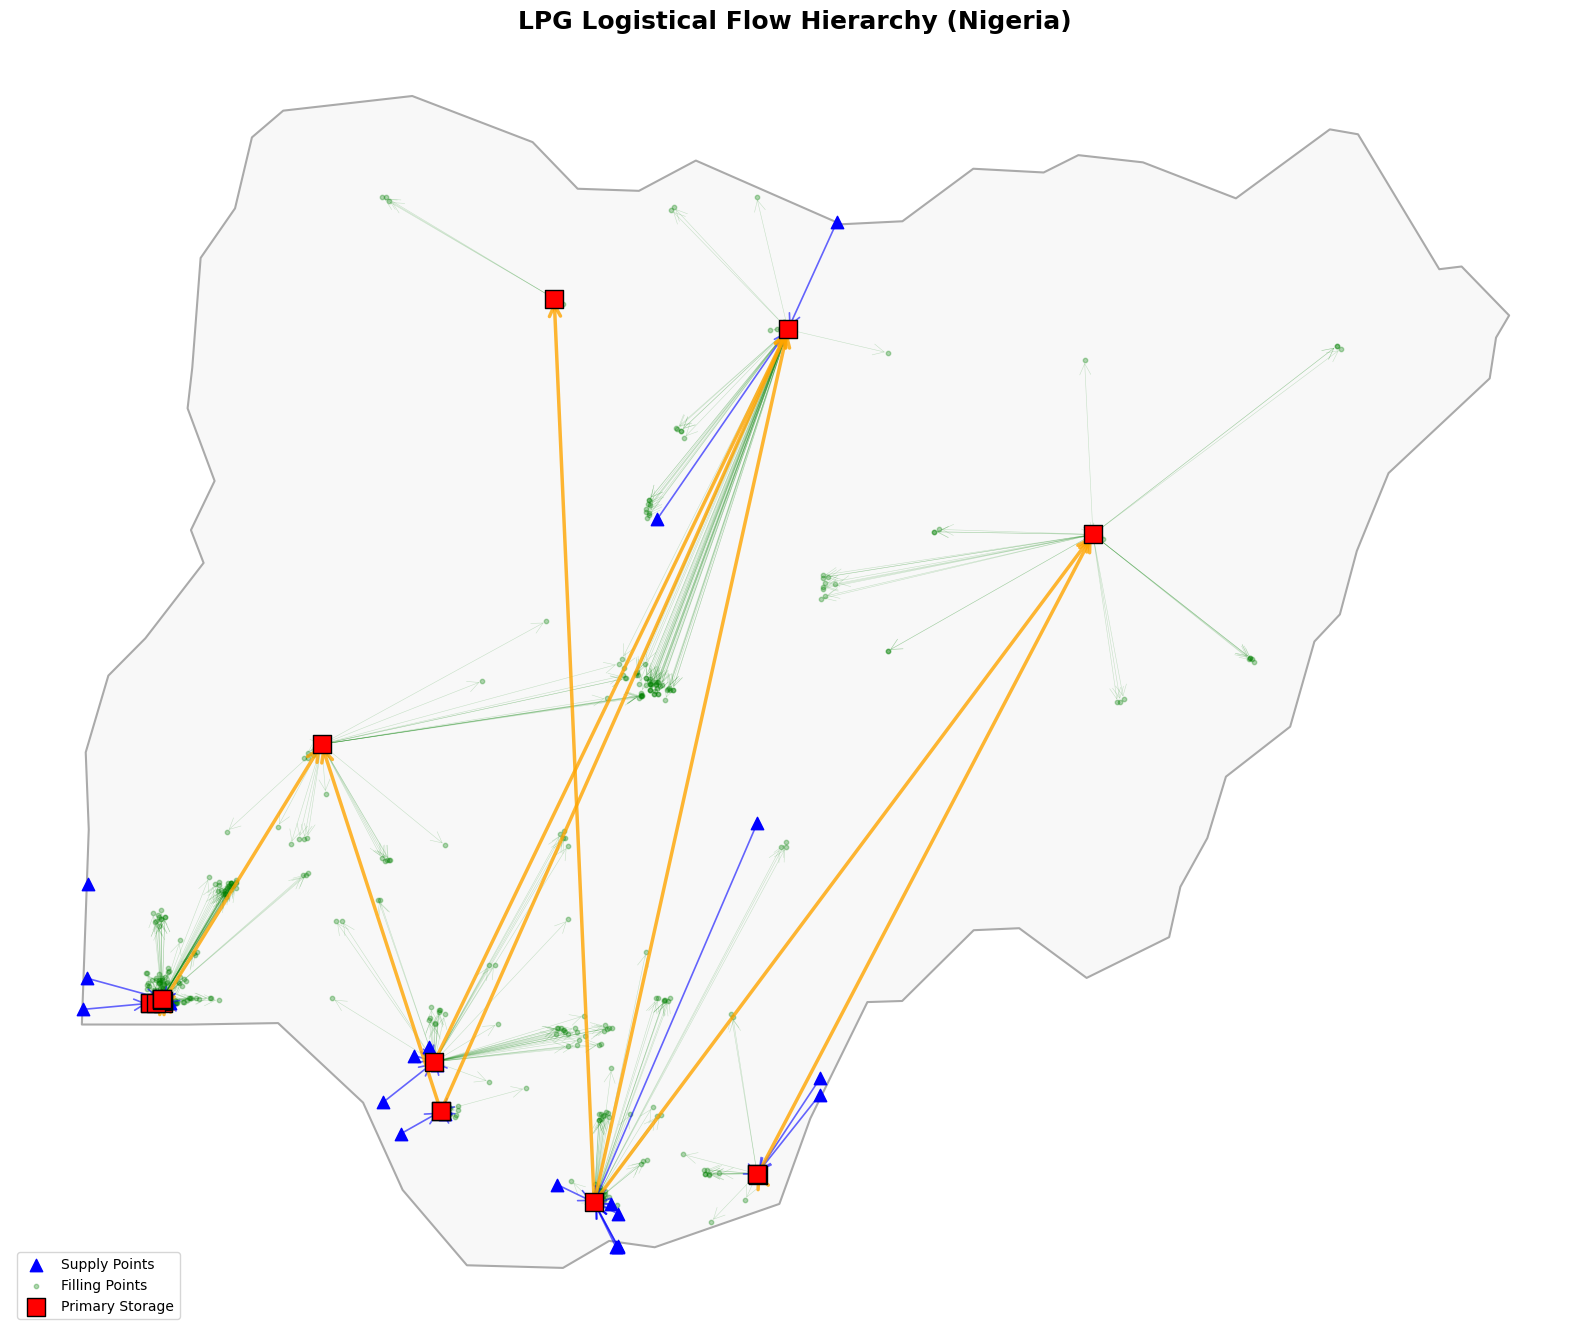

saved in: dataset_first_step\galga_flow.png
✓ first_step.gpkg updated (final export)


In [176]:
# Visualization of LPG supply chain with directional arrows:
# Blue: Source to Storage | Orange: Rebalancing | Green: Storage to Filling

warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS.*')

# 1. Load Data & Align CRS
ps = layers['primary_storage'].copy()
if 'filling_points' in layers and layers['filling_points'] is not None:
    filling = layers['filling_points'].copy()
else:
    filling_path = Path("dataset_big/filling_point_assigned.gpkg")
    filling = gpd.read_file(filling_path)

# Ensure CRS alignment
if filling.crs != ps.crs:
    filling = filling.to_crs(ps.crs)

# 2. Load Nigeria Background
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/NGA.geo.json"
nigeria_bg = gpd.read_file(url).to_crs(ps.crs)
print("Background map downloaded.")

# 3. Collect Supply Layers
supply_layers = ['refineries', 'ports', 'gas_plants', 'border_points']
supply_list = []
for lyr in supply_layers:
    gdf = layers.get(lyr)
    if gdf is None or gdf.empty:
        continue
    if gdf.crs != ps.crs:
        gdf = gdf.to_crs(ps.crs)
    supply_list.append(gdf)

supply = pd.concat(supply_list, ignore_index=True) if supply_list else gpd.GeoDataFrame()
ps_dict = {row['id_supply']: row.geometry.centroid for _, row in ps.iterrows()}

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(16, 16))

# Plot Background
if nigeria_bg is not None and not nigeria_bg.empty:
    nigeria_bg.plot(ax=ax, color='#f8f8f8', edgecolor='#aaaaaa', linewidth=1.5, zorder=0)
else:
    ax.set_facecolor('#fafafa')

def draw_arrow(start, end, color, lw, alpha, zorder=2, head_width=0.08):
    """
    Draw a styled arrow between two point geometries on the map.
    Uses annotate for consistent arrowheads and z-order control.
    Skips drawing when either endpoint is missing.
    Designed for readable, thin flow overlays.
    """
    if start is None or end is None:
        return
    ax.annotate("", xy=(end.x, end.y), xytext=(start.x, start.y),
                arrowprops=dict(arrowstyle="->", color=color, lw=lw, 
                                alpha=alpha, shrinkA=2, shrinkB=2, 
                                mutation_scale=20), zorder=zorder)

# 4. Draw Flows as Arrows
# A. Supply -> Primary Storage (Blue)
for _, row in supply.iterrows():
    tid = str(row.get('tank_id_supply', ''))
    if tid in ps_dict:
        draw_arrow(row.geometry.centroid, ps_dict[tid], 'blue', 1.2, 0.6)

# B. Rebalancing (Orange) - Thicker arrows
if 'allocation_matrix' in globals() and 'n_storage' in globals():
    for i in range(n_storage):
        for j in range(n_storage):
            if i != j and allocation_matrix[i, j] > 0.001:
                draw_arrow(ps.iloc[i].geometry.centroid, ps.iloc[j].geometry.centroid, 
                           'orange', 2.5, 0.8, zorder=3)

# C. Primary -> Filling (Green) - Subtle arrows
for _, row in filling.iterrows():
    tid = str(row.get('tank_id_supply', ''))
    if tid in ps_dict:
        draw_arrow(ps_dict[tid], row.geometry.centroid, 'green', 0.4, 0.2, zorder=1)

# 5. Plot Infrastructure Points
if not supply.empty:
    supply.centroid.plot(ax=ax, color='blue', marker='^', markersize=80, label='Supply Points', zorder=4)
filling.centroid.plot(ax=ax, color='green', marker='o', markersize=10, alpha=0.3, label='Filling Points', zorder=1)
ps.centroid.plot(ax=ax, color='red', marker='s', markersize=150, edgecolor='black', label='Primary Storage', zorder=5)

# Formatting
ax.set_title('LPG Logistical Flow Hierarchy (Nigeria)', fontsize=18, fontweight='bold')
ax.axis('off')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower left', frameon=True)

plt.tight_layout()

output_image_path = data_dir / "galga_flow.png"

plt.savefig(output_image_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print(f"saved in: {output_image_path}")

# Final export of all layers to first_step.gpkg
save_first_step(layers, "final export")

### 4.2. cost distribution histogram

✓ Charts saved successfully:
  - dataset_first_step\chart_1_complete_cost.png
  - dataset_first_step\chart_2_logistics_cost.png
  - dataset_first_step\chart_3_transport_pie.png


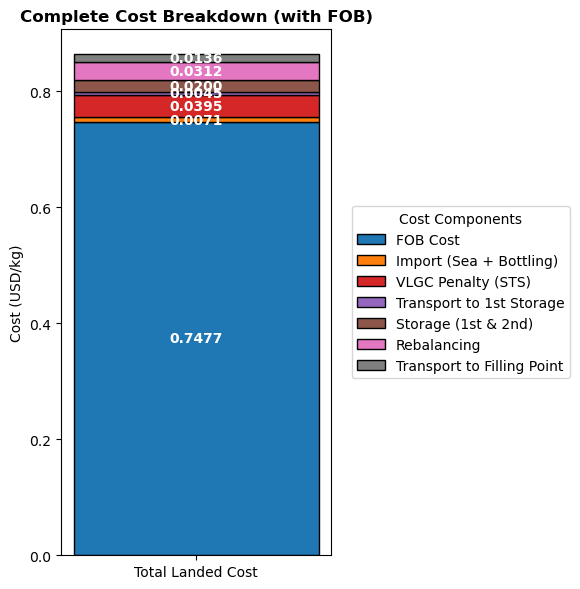

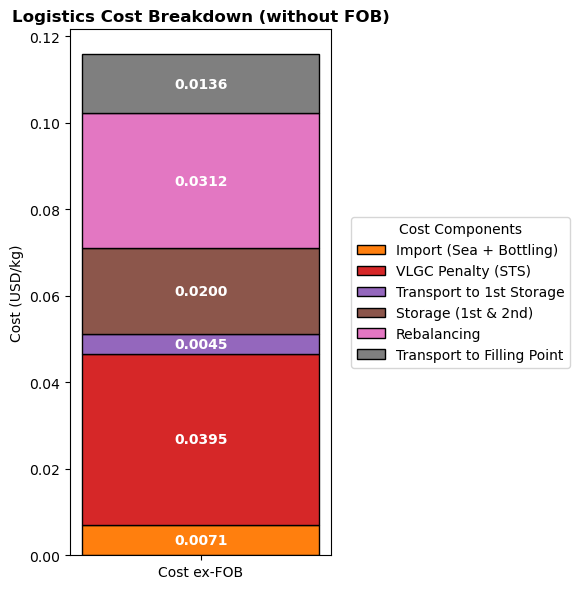

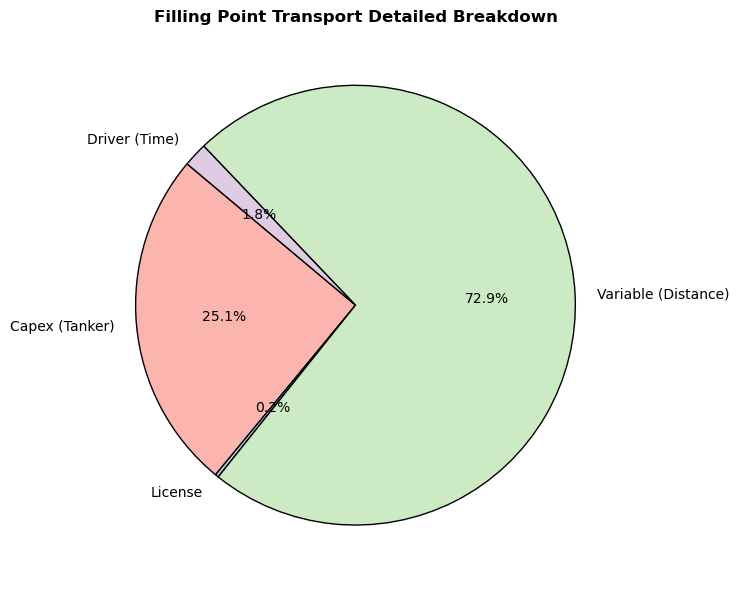

In [178]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load data
filling = layers['filling_points'].copy()

# Calculate actual weighted averages directly from the filling points layer
# Grouping similar sub-components for the plot as per your original logic
avg_import_sea = filling['cost_import_sea'].fillna(0).mean()
avg_pre_bottling = filling['cost_pre_bottling'].fillna(0).mean()
avg_sts = filling['cost_sts'].fillna(0).mean()
avg_import_land = filling['cost_import_land'].fillna(0).mean() + filling['cost_border_wait'].fillna(0).mean() + filling['cost_ferry'].fillna(0).mean()

avg_transp1 = filling['cost_transport_to_storage'].fillna(0).mean()
avg_storage_total = filling['cost_storage'].fillna(0).mean() + filling['cost_storage_second'].fillna(0).mean()
avg_rebal = filling['cost_rebalancing'].fillna(0).mean()
avg_transp2 = filling['cost_transport_from_storage'].fillna(0).mean()

avg_fob = filling['cost_source'].fillna(0).mean()  

cost_components = {
    'FOB Cost': avg_fob,
    'Import (Sea + Bottling)': avg_import_sea,
    'Import (Land + Border)': avg_import_land,
    'VLGC Penalty (STS)': avg_sts,
    'Transport to 1st Storage': avg_transp1,
    'Storage (1st & 2nd)': avg_storage_total,
    'Rebalancing': avg_rebal,
    'Transport to Filling Point': avg_transp2
}

# --- 2. DETAILED TRANSPORT COST BREAKDOWN ---

avg_dist_transp = filling['tank_distance'].fillna(0).mean()
avg_time_transp = filling['tank_traveltime'].fillna(0).mean()

effective_load_kg = tanker_capacity_kg * utilization_factor
variable_cost_per_km = 0.635
driver_hourly_cost_usd = (driver_annual_salary_usd * salary_multiplier) / (hours_per_day * days_per_year)
fixed_loading_unloading_hours = 1.0

annual_capital_cost_usd = tanker_overnight_cost_usd * crf(discount_rate, tanker_life_years)
annual_license_cost_usd = license_cost_usd * crf(discount_rate, licence_life_years)

# Using avg_dist_transp for the round trip calculation
avg_round_trip_km = 2.0 * avg_dist_transp
trips_per_year = tanker_annual_km / avg_round_trip_km if avg_round_trip_km > 0 else 1

capex_per_kg = annual_capital_cost_usd / (effective_load_kg * trips_per_year)
license_per_kg = annual_license_cost_usd / (effective_load_kg * trips_per_year)

round_trip_hours = (avg_time_transp * 2.0 / 60.0) + fixed_loading_unloading_hours
round_trip_distance_km = 2.0 * avg_dist_transp

distance_var_per_kg = (variable_cost_per_km * round_trip_distance_km) / effective_load_kg
driver_per_kg = (driver_hourly_cost_usd * round_trip_hours) / effective_load_kg

transport_components = {
    'Capex (Tanker)': capex_per_kg,
    'License': license_per_kg,
    'Variable (Distance)': distance_var_per_kg,
    'Driver (Time)': driver_per_kg
}

# --- 3. PLOTTING IN 3 SEPARATE FIGURES ---

colors = plt.cm.tab10.colors
bar_width = 0.2 

# Chart 1: Complete Stacked Bar Chart (Total Cost)
fig1, ax1 = plt.subplots(figsize=(6, 6))
bottom_total = 0
for i, (key, value) in enumerate(cost_components.items()):
    if value > 0:  
        ax1.bar('Total Landed Cost', value, bottom=bottom_total, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        # Centered text inside the block
        ax1.text(0, bottom_total + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        bottom_total += value

ax1.set_title('Complete Cost Breakdown (with FOB)', fontweight='bold')
ax1.set_ylabel('Cost (USD/kg)')
ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
fig1.tight_layout()
out1 = data_dir / "chart_1_complete_cost.png"
fig1.savefig(out1, dpi=300, bbox_inches='tight')

# Chart 2: Stacked Bar Chart WITHOUT FOB
fig2, ax2 = plt.subplots(figsize=(6, 6))
bottom_ex_fob = 0
for i, (key, value) in enumerate(cost_components.items()):
    if key != 'FOB Cost' and value > 0:  
        ax2.bar('Cost ex-FOB', value, bottom=bottom_ex_fob, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        ax2.text(0, bottom_ex_fob + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        bottom_ex_fob += value

ax2.set_title('Logistics Cost Breakdown (without FOB)', fontweight='bold')
ax2.set_ylabel('Cost (USD/kg)')
ax2.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
fig2.tight_layout()
out2 = data_dir / "chart_2_logistics_cost.png"
fig2.savefig(out2, dpi=300, bbox_inches='tight')

# Chart 3: Detailed Transport Breakdown (Pie Chart)
fig3, ax3 = plt.subplots(figsize=(7, 6))
ax3.pie(transport_components.values(), labels=transport_components.keys(), autopct='%1.1f%%', 
        colors=plt.cm.Pastel1.colors, startangle=140, wedgeprops={'edgecolor': 'black'})
ax3.set_title('Filling Point Transport Detailed Breakdown', fontweight='bold')
fig3.tight_layout()
out3 = data_dir / "chart_3_transport_pie.png"
fig3.savefig(out3, dpi=300, bbox_inches='tight')

print(f"✓ Charts saved successfully:\n  - {out1}\n  - {out2}\n  - {out3}")

### 4.3. Check average cost values